In [1]:
# Centroid-Based Clustering on the Pokemon Dataset
# Dataset: Pokemon with Stats (Gen 1-6), 800 rows

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

sns.set_style("whitegrid")
RANDOM_STATE = 42

In [ ]:
## Task 1: Data Loading & Exploration

In [7]:
df = pd.read_csv("Pokemon.csv")
df.head(10)

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False
5,5,Charmeleon,Fire,NaN,405,58,64,58,80,65,80,1,False
6,6,Charizard,Fire,Flying,534,78,84,78,109,85,100,1,False
7,6,CharizardMega Charizard X,Fire,Dragon,634,78,130,111,130,85,100,1,False
8,6,CharizardMega Charizard Y,Fire,Flying,634,78,104,78,159,115,100,1,False
9,7,Squirtle,Water,NaN,314,44,48,65,50,64,43,1,False


In [8]:
print("Shape:", df.shape)
print(df.dtypes)
df.describe()

Shape: (800, 13)
#              int64
Name          object
Type 1        object
Type 2        object
Total          int64
HP             int64
Attack         int64
Defense        int64
Sp. Atk        int64
Sp. Def        int64
Speed          int64
Generation     int64
Legendary       bool
dtype: object


,#,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation
count,800.000000,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.00000
mean,362.813750,435.10250,69.258750,79.001250,73.842500,72.820000,71.902500,68.277500,3.32375
std,208.343798,119.96304,25.534669,32.457366,31.183501,32.722294,27.828916,29.060474,1.66129
min,1.000000,180.00000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,1.00000
25%,184.750000,330.00000,50.000000,55.000000,50.000000,49.750000,50.000000,45.000000,2.00000
50%,364.500000,450.00000,65.000000,75.000000,70.000000,65.000000,70.000000,65.000000,3.00000
75%,539.250000,515.00000,80.000000,100.000000,90.000000,95.000000,90.000000,90.000000,5.00000
max,721.000000,780.00000,255.000000,190.000000,230.000000,194.000000,230.000000,180.000000,6.00000


In [9]:
print(df.isnull().sum())
df["Type 2"] = df["Type 2"].fillna("None")
print(df.isnull().sum())

#               0
Name            0
Type 1          0
Type 2        386
Total           0
HP              0
Attack          0
Defense         0
Sp. Atk         0
Sp. Def         0
Speed           0
Generation      0
Legendary       0
dtype: int64
#             0
Name          0
Type 1        0
Type 2        0
Total         0
HP            0
Attack        0
Defense       0
Sp. Atk       0
Sp. Def       0
Speed         0
Generation    0
Legendary     0
dtype: int64


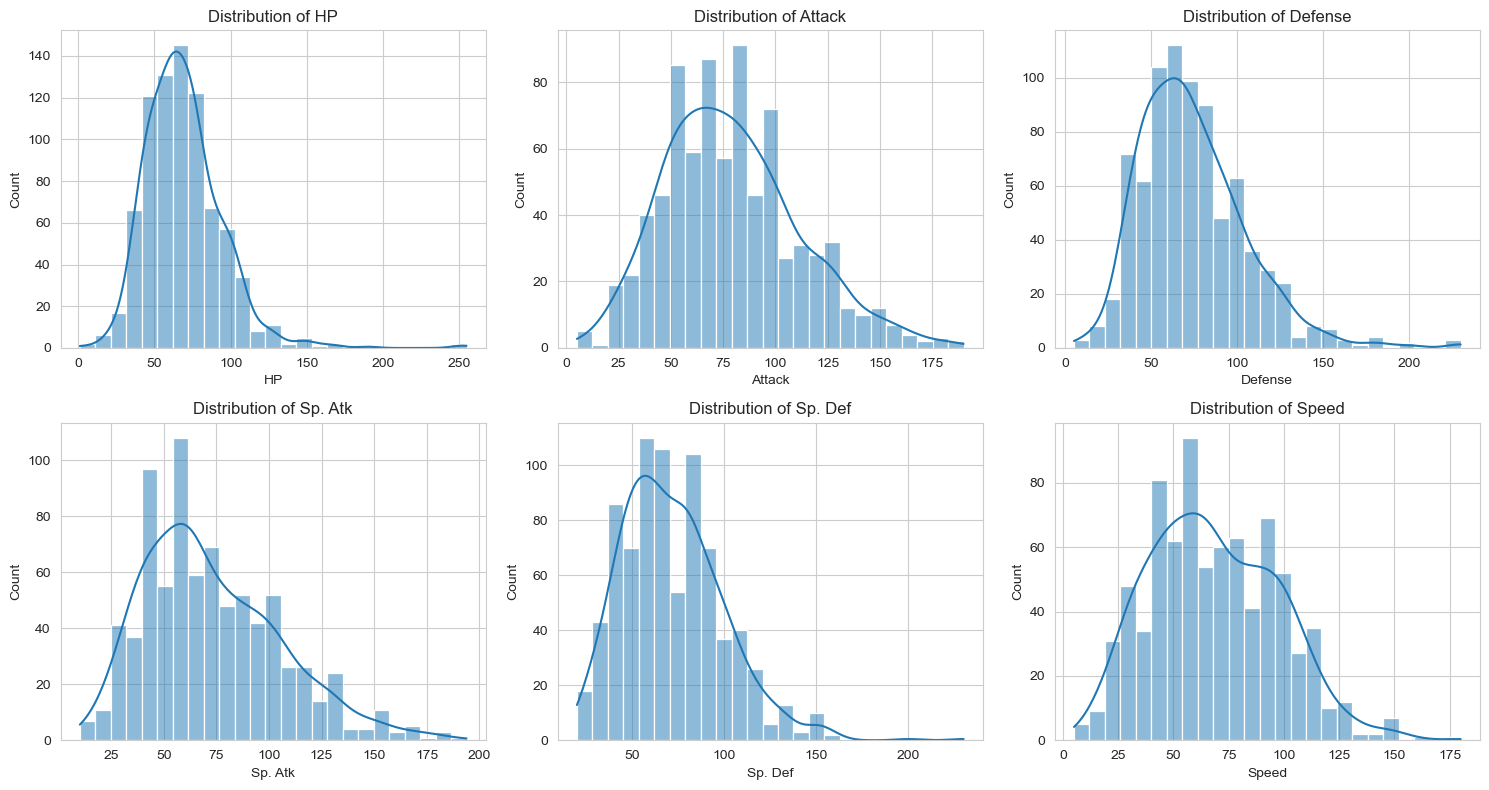

In [10]:
stats_cols = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), stats_cols):
    sns.histplot(df[col], kde=True, bins=25, ax=ax)
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

In [11]:
## Task 2: Data Preprocessing

In [12]:
features = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]
X = df[features].copy()
X.head()

,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
0,45,49,49,65,65,45
1,60,62,63,80,80,60
2,80,82,83,100,100,80
3,80,100,123,122,120,80
4,39,52,43,60,50,65


In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=features)
X_scaled.describe().round(2)

,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
count,800.00,800.00,800.00,800.00,800.00,800.00
mean,-0.00,0.00,-0.00,0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.67,-2.28,-2.21,-1.92,-1.87,-2.18
25%,-0.75,-0.74,-0.77,-0.71,-0.79,-0.80
50%,-0.17,-0.12,-0.12,-0.24,-0.07,-0.11
75%,0.42,0.65,0.52,0.68,0.65,0.75
max,7.28,3.42,5.01,3.71,5.68,3.85


In [14]:
le_type = LabelEncoder()
df["Type 1 Encoded"] = le_type.fit_transform(df["Type 1"])
df["Legendary Encoded"] = df["Legendary"].astype(int)
df[["Type 1", "Type 1 Encoded", "Legendary", "Legendary Encoded"]].head()

,Type 1,Type 1 Encoded,Legendary,Legendary Encoded
0,Grass,9,False,0
1,Grass,9,False,0
2,Grass,9,False,0
3,Grass,9,False,0
4,Fire,6,False,0


In [15]:
## Task 3: Determining Optimal K

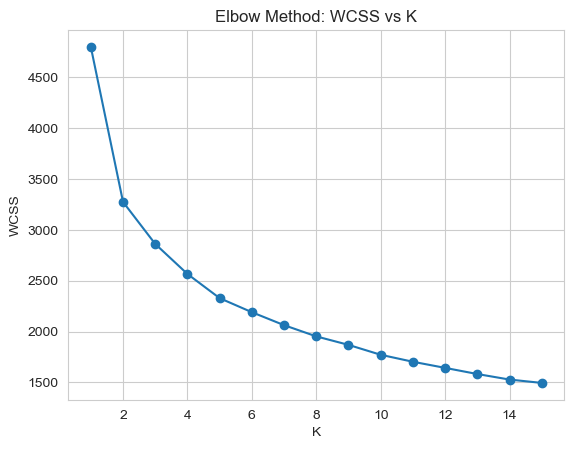

In [16]:
wcss = []
K_range = range(1, 16)
for k in K_range:
    km = KMeans(n_clusters=k, init="k-means++", random_state=RANDOM_STATE, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.plot(K_range, wcss, marker="o")
plt.title("Elbow Method: WCSS vs K")
plt.xlabel("K"); plt.ylabel("WCSS")
plt.show()

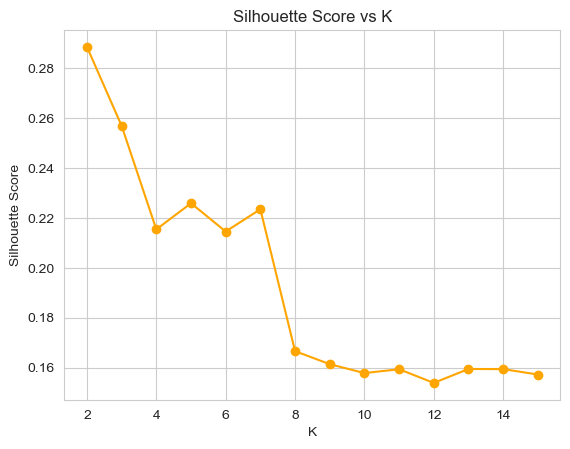

K=2: 0.2886
K=3: 0.2569
K=4: 0.2154
K=5: 0.2259
K=6: 0.2146
K=7: 0.2235
K=8: 0.1666
K=9: 0.1614
K=10: 0.1578
K=11: 0.1593
K=12: 0.1539
K=13: 0.1594
K=14: 0.1594
K=15: 0.1572


In [17]:
sil_scores = []
K_range_sil = range(2, 16)
for k in K_range_sil:
    km = KMeans(n_clusters=k, init="k-means++", random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.plot(list(K_range_sil), sil_scores, marker="o", color="orange")
plt.title("Silhouette Score vs K")
plt.xlabel("K"); plt.ylabel("Silhouette Score")
plt.show()

for k, s in zip(K_range_sil, sil_scores):
    print(f"K={k}: {s:.4f}")

In [18]:
K_OPTIMAL = 5

In [19]:
## Task 4: Applying K-Means Clustering

In [20]:
kmeans = KMeans(n_clusters=K_OPTIMAL, init="k-means++", random_state=RANDOM_STATE, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)
df[["Name", "Type 1", "HP", "Attack", "Speed", "Cluster"]].head(10)

,Name,Type 1,HP,Attack,Speed,Cluster
0,Bulbasaur,Grass,45,49,45,0
1,Ivysaur,Grass,60,62,60,4
2,Venusaur,Grass,80,82,80,4
3,VenusaurMega Venusaur,Grass,80,100,80,2
4,Charmander,Fire,39,52,65,0
5,Charmeleon,Fire,58,64,80,4
6,Charizard,Fire,78,84,100,4
7,CharizardMega Charizard X,Fire,78,130,100,2
8,CharizardMega Charizard Y,Fire,78,104,100,2
9,Squirtle,Water,44,48,43,0


In [21]:
centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)
centroids_df = pd.DataFrame(centroids_original, columns=features)
centroids_df.round(1)

,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
0,50.3,54.0,51.7,48.2,49.1,49.2
1,64.6,86.0,123.4,68.2,92.1,53.0
2,89.6,118.4,92.8,121.2,98.8,98.4
3,102.3,90.5,76.1,78.4,79.2,56.3
4,67.5,80.8,66.4,78.5,73.8,93.8


In [22]:
centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)
centroids_df = pd.DataFrame(centroids_original, columns=features)
centroids_df.round(1)

,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
0,50.3,54.0,51.7,48.2,49.1,49.2
1,64.6,86.0,123.4,68.2,92.1,53.0
2,89.6,118.4,92.8,121.2,98.8,98.4
3,102.3,90.5,76.1,78.4,79.2,56.3
4,67.5,80.8,66.4,78.5,73.8,93.8


In [23]:
for c in sorted(df["Cluster"].unique()):
    print(f"\n--- Cluster {c} ---")
    print(df[df["Cluster"] == c][["Name", "Type 1"]].sample(5, random_state=RANDOM_STATE))


--- Cluster 0 ---
         Name    Type 1
72     Machop  Fighting
438    Piplup     Water
697  Larvesta       Bug
740    Skiddo     Grass
280    Mudkip     Water

--- Cluster 1 ---
          Name    Type 1
251    Donphan    Ground
529   Dusknoir     Ghost
513  Magnezone  Electric
404  Relicanth     Water
380    Armaldo      Rock

--- Cluster 2 ---
                      Name  Type 1
424  GroudonPrimal Groudon  Ground
699               Cobalion   Steel
23     PidgeotMega Pidgeot  Normal
408              Salamence  Dragon
264                Suicune   Water

--- Cluster 3 ---
          Name    Type 1
593    Gurdurr  Fighting
67   Poliwrath     Water
281  Marshtomp     Water
515  Rhyperior    Ground
96         Muk    Poison

--- Cluster 4 ---
          Name    Type 1
60     Golduck     Water
146    Jolteon  Electric
644  Vanillish       Ice
461     Mothim       Bug
609  Lilligant     Grass


In [24]:
## Task 5: Visualization

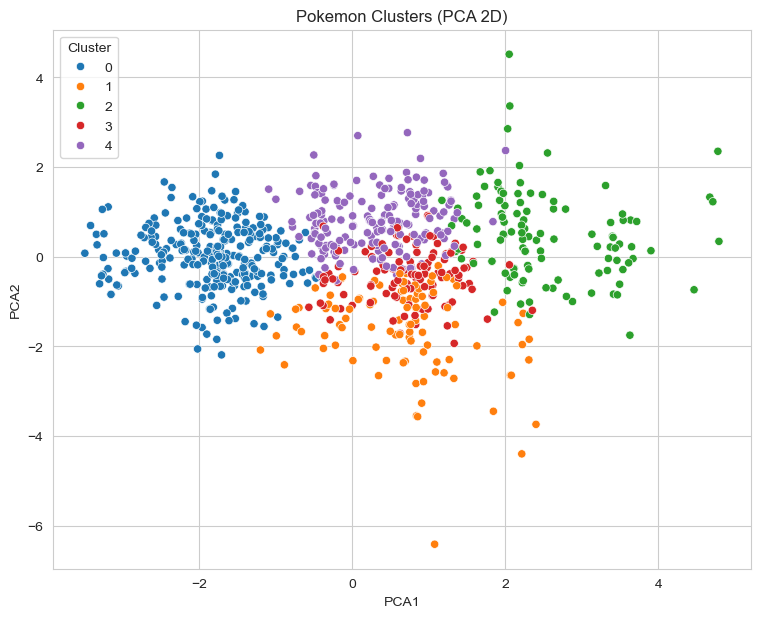

In [25]:
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
components = pca_2d.fit_transform(X_scaled)
df["PCA1"], df["PCA2"] = components[:, 0], components[:, 1]

plt.figure(figsize=(9,7))
sns.scatterplot(data=df, x="PCA1", y="PCA2", hue="Cluster", palette="tab10")
plt.title("Pokemon Clusters (PCA 2D)")
plt.show()

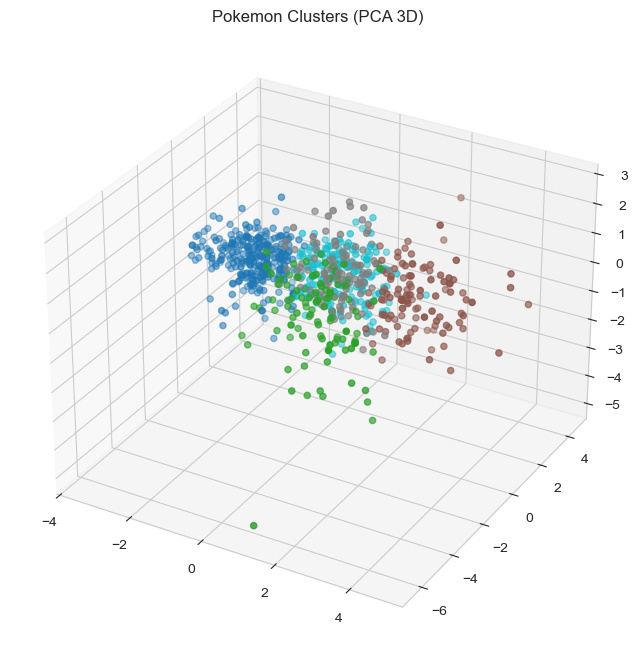

In [26]:
from mpl_toolkits.mplot3d import Axes3D
pca_3d = PCA(n_components=3, random_state=RANDOM_STATE)
comp3 = pca_3d.fit_transform(X_scaled)

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(comp3[:,0], comp3[:,1], comp3[:,2], c=df["Cluster"], cmap="tab10")
ax.set_title("Pokemon Clusters (PCA 3D)")
plt.show()

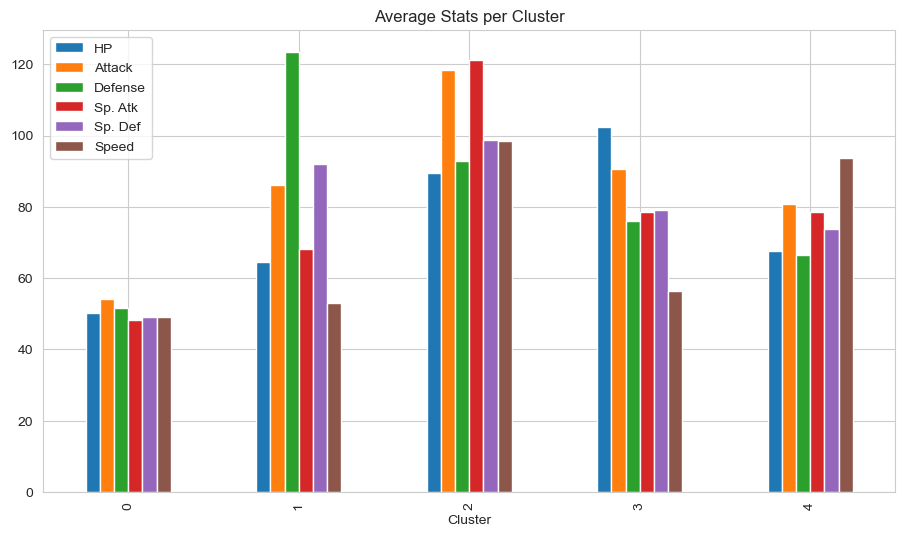

In [27]:
cluster_means = df.groupby("Cluster")[features].mean()
cluster_means.plot(kind="bar", figsize=(11,6))
plt.title("Average Stats per Cluster")
plt.show()

In [28]:
## Task 6: Analysis & Interpretation

In [29]:
overall_mean = df[features].mean()
comparison = cluster_means.subtract(overall_mean, axis=1).round(1)
comparison

,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
Cluster,,,,,,
0,-19.0,-25.0,-22.2,-24.7,-22.8,-19.1
1,-4.7,7.0,49.6,-4.6,20.2,-15.2
2,20.3,39.4,19.0,48.4,26.9,30.1
3,33.0,11.5,2.3,5.6,7.3,-11.9
4,-1.7,1.8,-7.4,5.7,1.9,25.5


In [30]:
legendary_by_cluster = df.groupby("Cluster")["Legendary"].sum()
print(legendary_by_cluster)
print("Most legendary in cluster:", legendary_by_cluster.idxmax())

Cluster
0     0
1     6
2    58
3     0
4     1
Name: Legendary, dtype: int64
Most legendary in cluster: 2


In [31]:
pd.crosstab(df["Type 1"], df["Cluster"])

Cluster,0,1,2,3,4
Type 1,,,,,
Bug,30,14,3,0,22
Dark,10,4,5,4,8
Dragon,5,1,19,1,6
Electric,12,6,7,4,15
Fairy,8,1,3,5,0
Fighting,9,2,1,7,8
Fire,13,2,13,6,18
Flying,1,0,2,0,1
Ghost,12,8,4,2,6


In [32]:
pd.crosstab(df["Generation"], df["Cluster"])

Cluster,0,1,2,3,4
Generation,,,,,
1,63,15,21,22,45
2,36,17,11,18,24
3,57,22,30,15,36
4,34,20,22,18,27
5,60,15,24,31,35
6,31,14,10,9,18


In [33]:
## Bonus: Mini-Batch K-Means vs K-Means

In [34]:
mbk = MiniBatchKMeans(n_clusters=K_OPTIMAL, random_state=RANDOM_STATE, n_init=10)
df["Cluster_MiniBatch"] = mbk.fit_predict(X_scaled)

print("KMeans Silhouette:", silhouette_score(X_scaled, df["Cluster"]))
print("KMeans Davies-Bouldin:", davies_bouldin_score(X_scaled, df["Cluster"]))
print("MiniBatch Silhouette:", silhouette_score(X_scaled, df["Cluster_MiniBatch"]))
print("MiniBatch Davies-Bouldin:", davies_bouldin_score(X_scaled, df["Cluster_MiniBatch"]))

KMeans Silhouette: 0.22590770488574197
KMeans Davies-Bouldin: 1.5150925677675304
MiniBatch Silhouette: 0.14459141927454752
MiniBatch Davies-Bouldin: 1.8499199395522719
